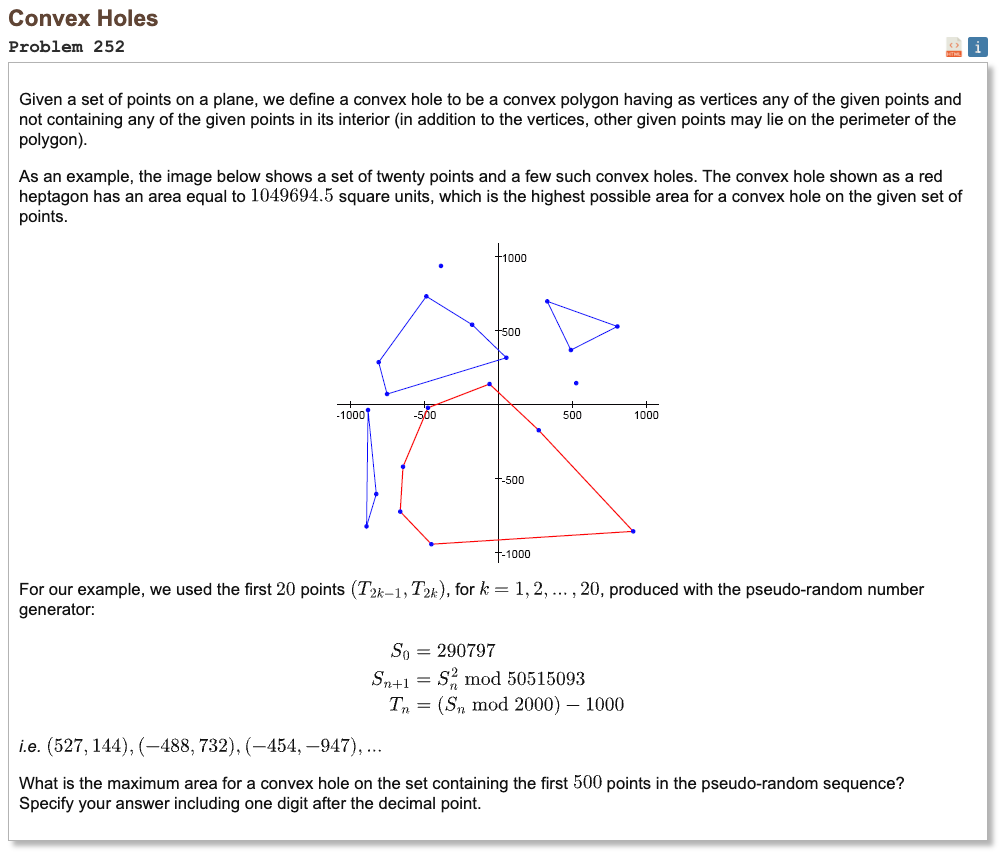

## Initial approach

* generate the 500 points using the given pseudo random rule
* a convex hole is a convex polygon made from these points with no other point strictly inside
* precompute which points lie to the left of every directed edge so emptiness checks become fast
* a triangle is valid only if no other point lies inside it
* build bigger convex polygons by extending valid triangles while keeping counterclockwise turns
* compute polygon area by adding triangle areas
* track the maximum area and print it with one decimal digit

In [1]:
from math import atan2

def gen_points(n):
    s = 290797
    pts = []
    for _ in range(n):
        s = (s * s) % 50515093
        x = s % 2000 - 1000
        s = (s * s) % 50515093
        y = s % 2000 - 1000
        pts.append((x, y))
    return pts

def area2(a, b, c):
    return abs((b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0]))

def cross(a, b, c):
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def build_left_masks(pts):
    n = len(pts)
    left = [[0] * n for _ in range(n)]
    for i in range(n):
        xi, yi = pts[i]
        for j in range(n):
            if i == j:
                continue
            xj, yj = pts[j]
            mask = 0
            for k in range(n):
                if k == i or k == j:
                    continue
                xk, yk = pts[k]
                v = (xj - xi) * (yk - yi) - (yj - yi) * (xk - xi)
                if v > 0:
                    mask |= 1 << k
            left[i][j] = mask
    return left

def tri_empty(i, j, k, left_masks):
    m = left_masks[i][j] & left_masks[j][k] & left_masks[k][i]
    return m == 0

def solve():
    pts = gen_points(500)
    n = len(pts)
    left_masks = build_left_masks(pts)

    max_a2 = 0

    for r in range(n):
        others = [i for i in range(n) if i != r]
        rx, ry = pts[r]
        others.sort(key=lambda i: atan2(pts[i][1] - ry, pts[i][0] - rx))
        m = len(others)

        dp = [[-1] * m for _ in range(m)]
        for a in range(m):
            for b in range(a + 1, m):
                i = others[a]
                j = others[b]
                if cross(pts[r], pts[i], pts[j]) > 0 and tri_empty(r, i, j, left_masks):
                    dp[a][b] = area2(pts[r], pts[i], pts[j])
                    if dp[a][b] > max_a2:
                        max_a2 = dp[a][b]

        for a in range(m):
            for b in range(a + 1, m):
                if dp[a][b] < 0:
                    continue
                i = others[a]
                j = others[b]
                for c in range(b + 1, m):
                    k = others[c]
                    if cross(pts[i], pts[j], pts[k]) <= 0:
                        continue
                    if cross(pts[r], pts[j], pts[k]) <= 0:
                        continue
                    if not tri_empty(r, j, k, left_masks):
                        continue
                    val = dp[a][b] + area2(pts[r], pts[j], pts[k])
                    if val > dp[b][c]:
                        dp[b][c] = val
                        if val > max_a2:
                            max_a2 = val

    if max_a2 % 2 == 0:
        out = f"{max_a2 // 2}.0"
    else:
        out = f"{max_a2 // 2}.5"
    print("Result:", out)

In [2]:
%%time
solve()

Result: 191439.0
CPU times: user 2min 5s, sys: 518 ms, total: 2min 6s
Wall time: 2min 7s
